In [1]:
import sys
from pathlib import Path

# Add HealthLens ML source folder to Python path
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root / "ml" / "src"))

from load_data import load_dataset

df = load_dataset()

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# Dataset dimensions
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Rows: 768
Columns: 9

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [3]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing values: 0


In [4]:
# Check zero values in each column

zero_counts = (df == 0).sum()

print("Zero values in each column:")
print(zero_counts)

Zero values in each column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [5]:
# Target class distribution

outcome_counts = df["Outcome"].value_counts().sort_index()

print("Outcome counts:")
print(outcome_counts)

print("\nOutcome percentages:")
print((outcome_counts / len(df) * 100).round(2))

Outcome counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome percentages:
Outcome
0    65.1
1    34.9
Name: count, dtype: float64


In [6]:
# Summary statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


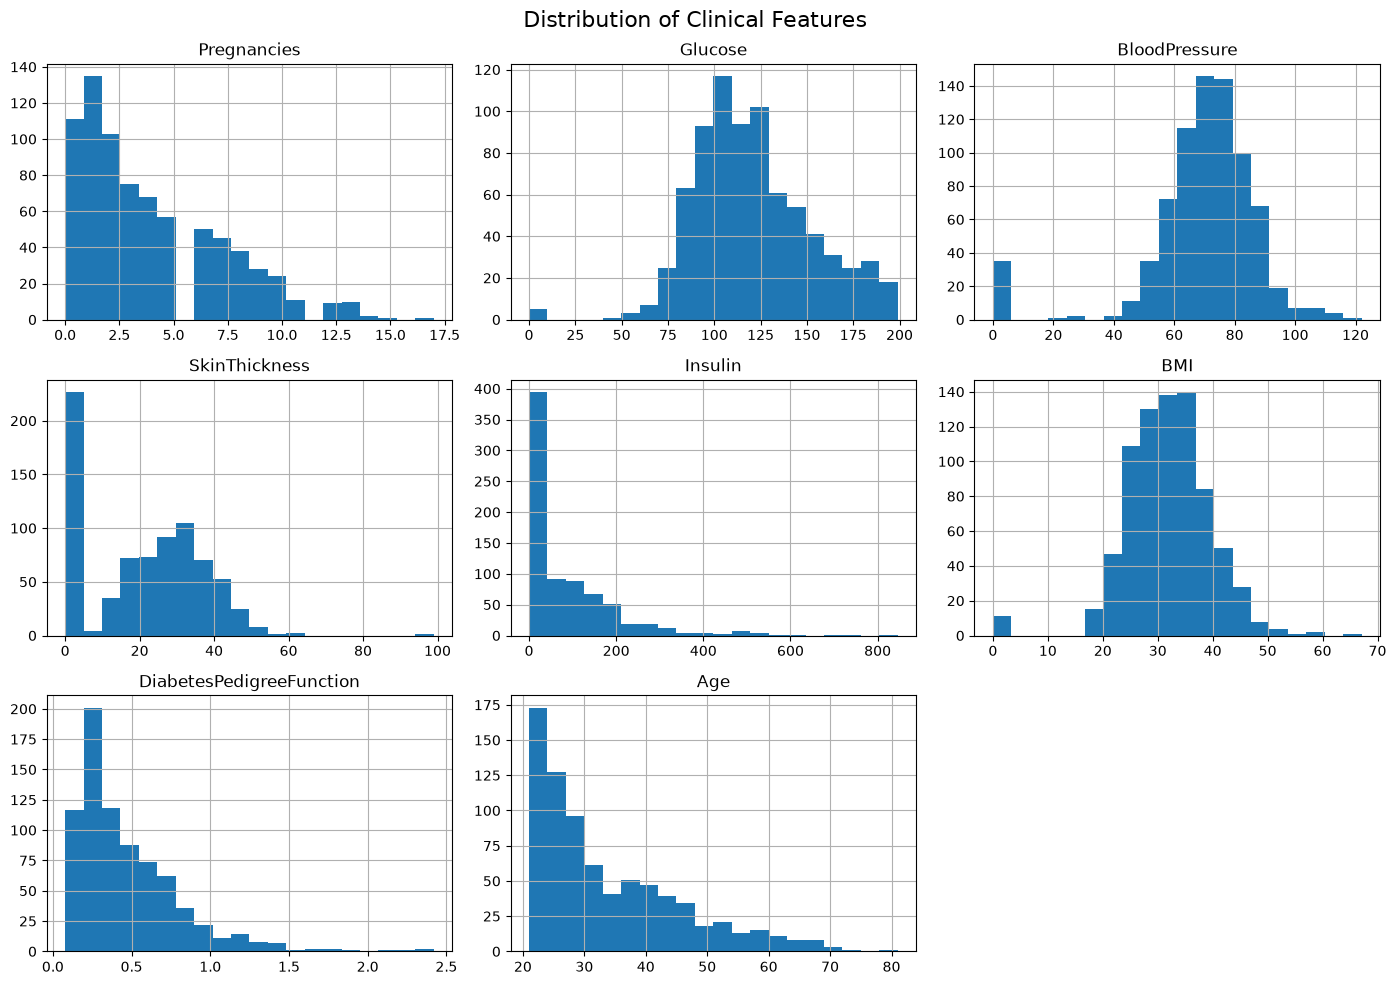

In [7]:
import matplotlib.pyplot as plt

# Numerical features to visualize
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

# Create distribution plots
df[features].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Distribution of Clinical Features", fontsize=16)
plt.tight_layout()
plt.show()

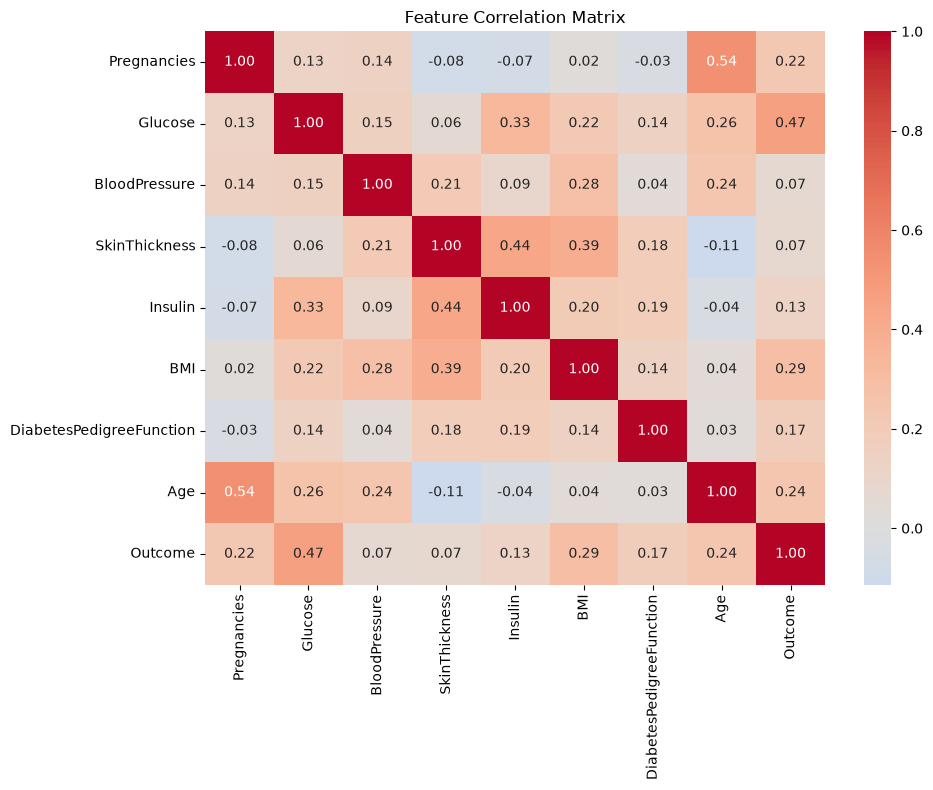

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

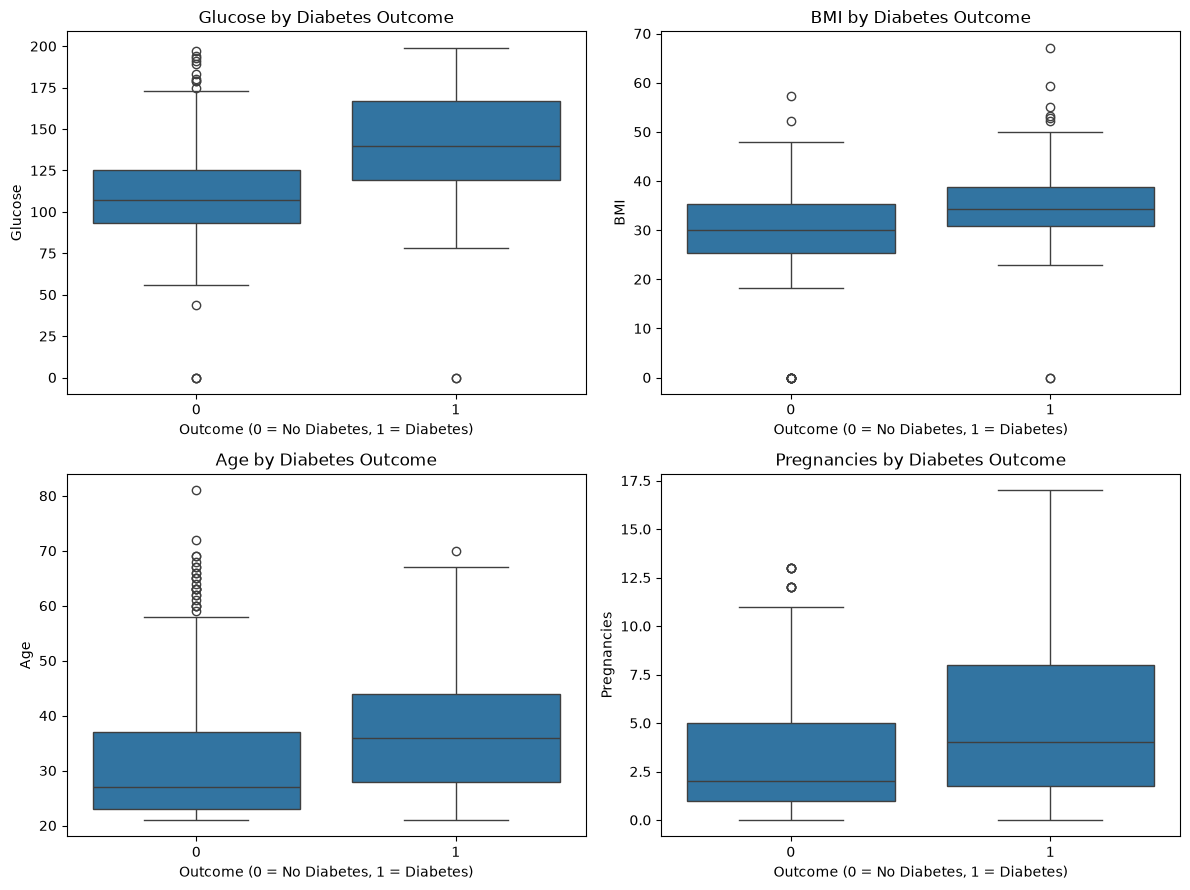

In [9]:
# Compare important features by diabetes outcome

features_to_compare = [
    "Glucose",
    "BMI",
    "Age",
    "Pregnancies"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feature in zip(axes.flat, features_to_compare):
    sns.boxplot(
        data=df,
        x="Outcome",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} by Diabetes Outcome")
    ax.set_xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")

plt.tight_layout()
plt.show()

In [10]:
from sklearn.impute import SimpleImputer

# Columns where zero represents a missing/implausible measurement
zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Create a copy so the original raw dataset remains unchanged
df_clean = df.copy()

# Replace invalid zeros with NaN
df_clean[zero_as_missing] = df_clean[zero_as_missing].replace(
    0, float("nan")
)

# Impute missing values using the median
imputer = SimpleImputer(strategy="median")

df_clean[zero_as_missing] = imputer.fit_transform(
    df_clean[zero_as_missing]
)

print("Remaining missing values:")
print(df_clean[zero_as_missing].isnull().sum())

print("\nCleaned dataset shape:")
print(df_clean.shape)

Remaining missing values:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Cleaned dataset shape:
(768, 9)


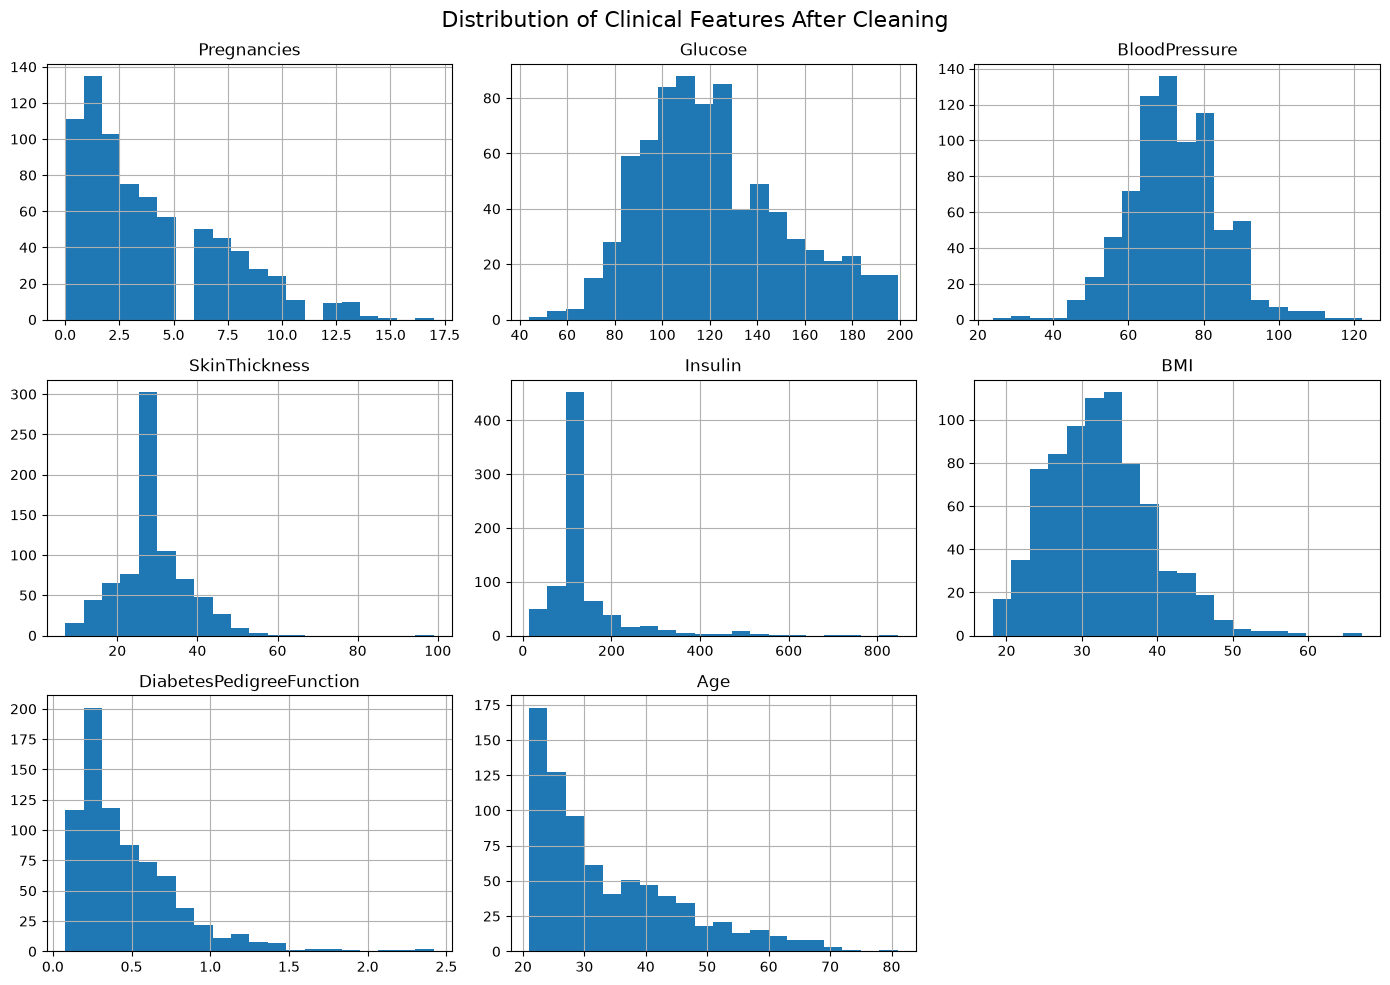

In [11]:
# Distribution of cleaned clinical features

df_clean[features].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle(
    "Distribution of Clinical Features After Cleaning",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

# Feature Engineering

# Create a copy of the cleaned dataset
df_engineered = df_clean.copy()

# 1. BMI categories
df_engineered["BMI_Category"] = pd.cut(
    df_engineered["BMI"],
    bins=[0, 18.5, 25, 30, float("inf")],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ],
    include_lowest=True
)

# 2. Age bands
df_engineered["Age_Band"] = pd.cut(
    df_engineered["Age"],
    bins=[0, 30, 45, 60, float("inf")],
    labels=[
        "Young",
        "Adult",
        "Middle_Age",
        "Senior"
    ],
    include_lowest=True
)

# 3. Glucose-to-insulin ratio
df_engineered["Glucose_Insulin_Ratio"] = (
    df_engineered["Glucose"] /
    df_engineered["Insulin"]
)

# 4. BMI × Age interaction
df_engineered["BMI_Age_Interaction"] = (
    df_engineered["BMI"] *
    df_engineered["Age"]
)

# Display results
print("Original dataset shape:")
print(df_clean.shape)

print("\nEngineered dataset shape:")
print(df_engineered.shape)

print("\nNew features:")
print([
    "BMI_Category",
    "Age_Band",
    "Glucose_Insulin_Ratio",
    "BMI_Age_Interaction"
])

print("\nFirst 5 rows of engineered dataset:")
df_engineered.head()

Original dataset shape:
(768, 9)

Engineered dataset shape:
(768, 13)

New features:
['BMI_Category', 'Age_Band', 'Glucose_Insulin_Ratio', 'BMI_Age_Interaction']

First 5 rows of engineered dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Band,Glucose_Insulin_Ratio,BMI_Age_Interaction
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Obese,Middle_Age,1.184000,1680.0
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,Overweight,Adult,0.680000,824.6
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,Normal,Adult,1.464000,745.6
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,Young,0.946809,590.1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obese,Adult,0.815476,1422.3
